In [1]:
# Install required packages if needed
!pip install pandas numpy matplotlib seaborn openpyxl -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

print("Uploaded file:", file_name)

Saving Titan_Deloitte_Project_Data.xlsx to Titan_Deloitte_Project_Data.xlsx
Uploaded file: Titan_Deloitte_Project_Data.xlsx


In [4]:
financials = pd.read_excel(
    file_name,
    sheet_name="Titan_Financials"
)

segments = pd.read_excel(
    file_name,
    sheet_name="Titan_Segments"
)

peers = pd.read_excel(
    file_name,
    sheet_name="Peer_Benchmark"
)

industry = pd.read_excel(
    file_name,
    sheet_name="Industry_Context"
)

sources = pd.read_excel(
    file_name,
    sheet_name="Sources_Notes"
)

print("All datasets loaded successfully.")

All datasets loaded successfully.


In [5]:
print("FINANCIALS")
display(financials)

print("\nSEGMENTS")
display(segments)

print("\nPEERS")
display(peers)

print("\nINDUSTRY")
display(industry)

FINANCIALS


,FY,Revenue_from_operations_₹Cr,Total_income_₹Cr,EBITDA_proxy_₹Cr,PBT_₹Cr,PAT_₹Cr,Revenue_growth_%,EBITDA_margin_%,PAT_margin_%,EBITDA Growth %,PAT Growth %,EBITDA Margin Change,PAT Margin Change
0,FY2022,"28,799.00","29,033.00","3,575.00","2,904.00","2,198.00",NaN,12.31,7.57,NaN,NaN,NaN,NaN
1,FY2023,"40,575.00","40,883.00","5,187.00","4,447.00","3,274.00",40.89,12.69,8.01,0.45,0.49,0.37,0.44
2,FY2024,"51,084.00","51,617.00","5,825.00","4,623.00","3,496.00",25.90,11.29,6.77,0.12,0.07,-1.40,-1.24
3,FY2025,"60,456.00","60,942.00","6,180.00","4,535.00","3,337.00",18.35,10.14,5.48,0.06,-0.05,-1.14,-1.30
4,FY2026,"87,584.00","88,136.00","8,907.00","6,801.00","5,073.00",44.87,10.11,5.76,0.44,0.52,-0.03,0.28
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Revenue CAGR FY22-FY26,0.32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,EBITDA CAGR FY22-FY26,0.26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,PAT CAGR FY22-FY26,0.23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



SEGMENTS


,FY,Watches_revenue_₹Cr,Jewellery_revenue_₹Cr,Eyecare_revenue_₹Cr,Others_revenue_₹Cr,Watches_profit_₹Cr,Jewellery_profit_₹Cr,Eyecare_profit_₹Cr,Others_profit_₹Cr
0,FY2022,2309,24313,517,154,108,3027,50,-36
1,FY2023,3296,34105,689,295,413,4363,98,-78
2,FY2024,3904,42292,724,378,397,4726,85,-93
3,FY2025,4576,49227,796,406,553,4764,85,-124
4,FY2026,5233,71108,907,508,842,6601,84,-114



PEERS


,Company,Total_income_₹Cr,EBITDA_₹Cr,PAT_₹Cr,EBITDA_margin_%,PAT_margin_%
0,Titan (FY2025),"60,942.00","6,180.00","3,337.00",10.14,5.48
1,Kalyan Jewellers (FY2025),"25,189.67","1,517.20",714.17,6.02,2.84
2,Senco Gold (FY2025),"6,382.64",367.63,159.31,5.76,2.50
3,Ethos (FY2025),"1,275.93",214.30,96.30,16.80,7.55



INDUSTRY


,Indicator,Value,Source
0,India gold jewellery demand volume FY2025,430.5 tonnes,World Gold Council
1,India gold jewellery demand volume change 2025,-24% YoY,World Gold Council
2,India gold jewellery demand value FY2025,US$49 billion,World Gold Council
3,India domestic gold price change during 2025,+74%,World Gold Council
4,India jewellery demand volume Q1 2026,66.1 tonnes,World Gold Council
5,India jewellery demand value Q1 2026,INR 999 billion,World Gold Council


In [6]:
print("Missing values in Financials:")
display(financials.isnull().sum())

print("\nMissing values in Segments:")
display(segments.isnull().sum())

print("\nMissing values in Peers:")
display(peers.isnull().sum())

Missing values in Financials:


,0
FY,1
Revenue_from_operations_₹Cr,1
Total_income_₹Cr,4
EBITDA_proxy_₹Cr,4
PBT_₹Cr,4
PAT_₹Cr,4
Revenue_growth_%,5
EBITDA_margin_%,4
PAT_margin_%,4
EBITDA Growth %,5



Missing values in Segments:


,0
FY,0
Watches_revenue_₹Cr,0
Jewellery_revenue_₹Cr,0
Eyecare_revenue_₹Cr,0
Others_revenue_₹Cr,0
Watches_profit_₹Cr,0
Jewellery_profit_₹Cr,0
Eyecare_profit_₹Cr,0
Others_profit_₹Cr,0



Missing values in Peers:


,0
Company,0
Total_income_₹Cr,0
EBITDA_₹Cr,0
PAT_₹Cr,0
EBITDA_margin_%,0
PAT_margin_%,0


In [7]:
financials["Revenue_Growth_%"] = (
    financials["Revenue_from_operations_₹Cr"]
    .pct_change() * 100
)

/tmp/ipykernel_667/1481522091.py:3: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  .pct_change() * 100


In [8]:
financials["EBITDA_Growth_%"] = (
    financials["EBITDA_proxy_₹Cr"]
    .pct_change() * 100
)

/tmp/ipykernel_667/1867534256.py:3: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  .pct_change() * 100


In [9]:
financials["PAT_Growth_%"] = (
    financials["PAT_₹Cr"]
    .pct_change() * 100
)

/tmp/ipykernel_667/2850611846.py:3: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  .pct_change() * 100


In [10]:
financials["EBITDA_Margin_Calc_%"] = (
    financials["EBITDA_proxy_₹Cr"]
    / financials["Total_income_₹Cr"]
) * 100

financials["PAT_Margin_Calc_%"] = (
    financials["PAT_₹Cr"]
    / financials["Total_income_₹Cr"]
) * 100

In [11]:
financial_analysis = financials[
    [
        "FY",
        "Revenue_from_operations_₹Cr",
        "Revenue_Growth_%",
        "EBITDA_proxy_₹Cr",
        "EBITDA_Growth_%",
        "EBITDA_Margin_Calc_%",
        "PAT_₹Cr",
        "PAT_Growth_%",
        "PAT_Margin_Calc_%"
    ]
]

display(financial_analysis.round(2))

,FY,Revenue_from_operations_₹Cr,Revenue_Growth_%,EBITDA_proxy_₹Cr,EBITDA_Growth_%,EBITDA_Margin_Calc_%,PAT_₹Cr,PAT_Growth_%,PAT_Margin_Calc_%
0,FY2022,"28,799.00",NaN,"3,575.00",NaN,12.31,"2,198.00",NaN,7.57
1,FY2023,"40,575.00",40.89,"5,187.00",45.09,12.69,"3,274.00",48.95,8.01
2,FY2024,"51,084.00",25.90,"5,825.00",12.30,11.29,"3,496.00",6.78,6.77
3,FY2025,"60,456.00",18.35,"6,180.00",6.09,10.14,"3,337.00",-4.55,5.48
4,FY2026,"87,584.00",44.87,"8,907.00",44.13,10.11,"5,073.00",52.02,5.76
5,NaN,NaN,0.00,NaN,0.00,NaN,NaN,0.00,NaN
6,Revenue CAGR FY22-FY26,0.32,-100.00,NaN,0.00,NaN,NaN,0.00,NaN
7,EBITDA CAGR FY22-FY26,0.26,-20.03,NaN,0.00,NaN,NaN,0.00,NaN
8,PAT CAGR FY22-FY26,0.23,-9.28,NaN,0.00,NaN,NaN,0.00,NaN


In [14]:
start = financials.iloc[0]
end = financials.iloc[-1]

years = len(financials) - 1

revenue_cagr = (
    (end["Revenue_from_operations_₹Cr"] /
     start["Revenue_from_operations_₹Cr"]) ** (1 / years)
) - 1

ebitda_cagr = (
    (end["EBITDA_proxy_₹Cr"] /
     start["EBITDA_proxy_₹Cr"]) ** (1 / years)
) - 1

pat_cagr = (
    (end["PAT_₹Cr"] /
     start["PAT_₹Cr"]) ** (1 / years)
) - 1

cagr_table = pd.DataFrame({
    "Metric": [
        "Revenue",
        "EBITDA",
        "PAT"
    ],
    "FY22-FY26 CAGR": [
        revenue_cagr * 100,
        ebitda_cagr * 100,
        pat_cagr * 100
    ]
})

display(cagr_table.round(2))

,Metric,FY22-FY26 CAGR
0,Revenue,-76.91
1,EBITDA,NaN
2,PAT,NaN


In [15]:
# Keep ONLY the actual financial-year rows
financials = financials[
    financials["FY"].astype(str).str.match(r"^FY20\d{2}$")
].copy()

financials = financials.reset_index(drop=True)

display(financials)

,FY,Revenue_from_operations_₹Cr,Total_income_₹Cr,EBITDA_proxy_₹Cr,PBT_₹Cr,PAT_₹Cr,Revenue_growth_%,EBITDA_margin_%,PAT_margin_%,EBITDA Growth %,PAT Growth %,EBITDA Margin Change,PAT Margin Change,Revenue_Growth_%,EBITDA_Growth_%,PAT_Growth_%,EBITDA_Margin_Calc_%,PAT_Margin_Calc_%
0,FY2022,"28,799.00","29,033.00","3,575.00","2,904.00","2,198.00",NaN,12.31,7.57,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.31,7.57
1,FY2023,"40,575.00","40,883.00","5,187.00","4,447.00","3,274.00",40.89,12.69,8.01,0.45,0.49,0.37,0.44,40.89,45.09,48.95,12.69,8.01
2,FY2024,"51,084.00","51,617.00","5,825.00","4,623.00","3,496.00",25.90,11.29,6.77,0.12,0.07,-1.40,-1.24,25.90,12.30,6.78,11.29,6.77
3,FY2025,"60,456.00","60,942.00","6,180.00","4,535.00","3,337.00",18.35,10.14,5.48,0.06,-0.05,-1.14,-1.30,18.35,6.09,-4.55,10.14,5.48
4,FY2026,"87,584.00","88,136.00","8,907.00","6,801.00","5,073.00",44.87,10.11,5.76,0.44,0.52,-0.03,0.28,44.87,44.13,52.02,10.11,5.76


In [16]:
# Make sure financial columns are numeric

financial_columns = [
    "Revenue_from_operations_₹Cr",
    "Total_income_₹Cr",
    "EBITDA_proxy_₹Cr",
    "PBT_₹Cr",
    "PAT_₹Cr"
]

for col in financial_columns:
    financials[col] = pd.to_numeric(
        financials[col],
        errors="coerce"
    )

display(
    financials[
        ["FY"] + financial_columns
    ]
)

,FY,Revenue_from_operations_₹Cr,Total_income_₹Cr,EBITDA_proxy_₹Cr,PBT_₹Cr,PAT_₹Cr
0,FY2022,"28,799.00","29,033.00","3,575.00","2,904.00","2,198.00"
1,FY2023,"40,575.00","40,883.00","5,187.00","4,447.00","3,274.00"
2,FY2024,"51,084.00","51,617.00","5,825.00","4,623.00","3,496.00"
3,FY2025,"60,456.00","60,942.00","6,180.00","4,535.00","3,337.00"
4,FY2026,"87,584.00","88,136.00","8,907.00","6,801.00","5,073.00"


In [17]:
start = financials.iloc[0]
end = financials.iloc[-1]

years = 4

revenue_cagr = (
    (end["Revenue_from_operations_₹Cr"] /
     start["Revenue_from_operations_₹Cr"])
    ** (1 / years)
) - 1

ebitda_cagr = (
    (end["EBITDA_proxy_₹Cr"] /
     start["EBITDA_proxy_₹Cr"])
    ** (1 / years)
) - 1

pat_cagr = (
    (end["PAT_₹Cr"] /
     start["PAT_₹Cr"])
    ** (1 / years)
) - 1

cagr_table = pd.DataFrame({
    "Metric": [
        "Revenue",
        "EBITDA",
        "PAT"
    ],
    "FY22-FY26 CAGR": [
        revenue_cagr * 100,
        ebitda_cagr * 100,
        pat_cagr * 100
    ]
})

display(cagr_table.round(2))

,Metric,FY22-FY26 CAGR
0,Revenue,32.06
1,EBITDA,25.64
2,PAT,23.26


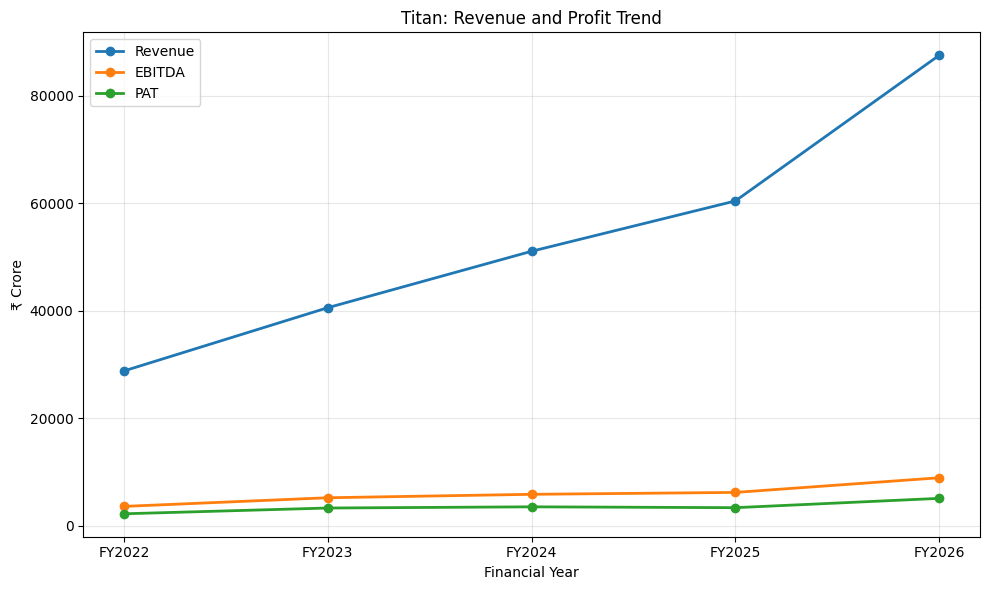

In [18]:
plt.figure(figsize=(10, 6))

plt.plot(
    financials["FY"],
    financials["Revenue_from_operations_₹Cr"],
    marker="o",
    linewidth=2,
    label="Revenue"
)

plt.plot(
    financials["FY"],
    financials["EBITDA_proxy_₹Cr"],
    marker="o",
    linewidth=2,
    label="EBITDA"
)

plt.plot(
    financials["FY"],
    financials["PAT_₹Cr"],
    marker="o",
    linewidth=2,
    label="PAT"
)

plt.title("Titan: Revenue and Profit Trend")
plt.xlabel("Financial Year")
plt.ylabel("₹ Crore")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

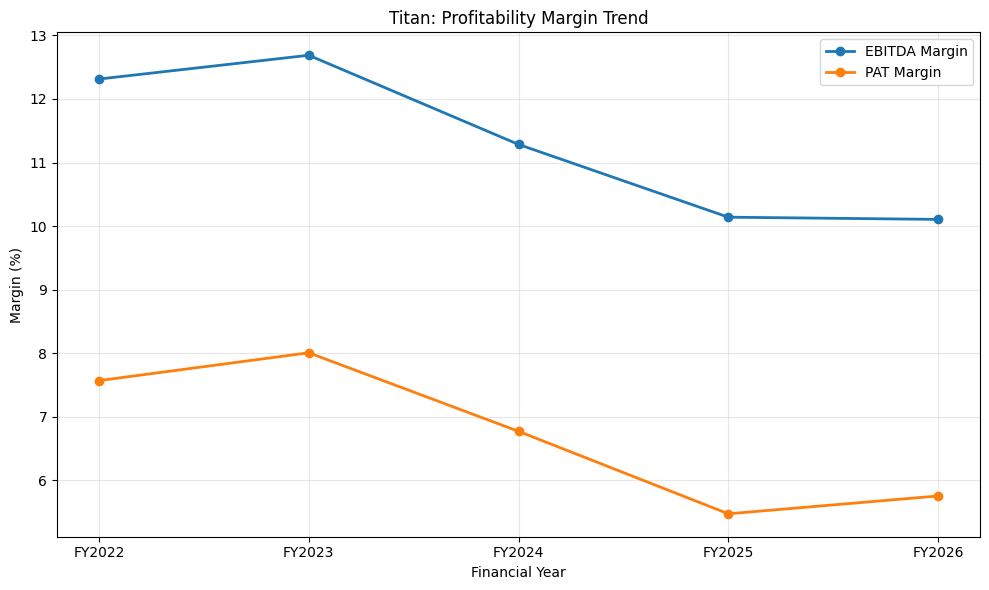

In [19]:
plt.figure(figsize=(10, 6))

plt.plot(
    financials["FY"],
    financials["EBITDA_Margin_Calc_%"],
    marker="o",
    linewidth=2,
    label="EBITDA Margin"
)

plt.plot(
    financials["FY"],
    financials["PAT_Margin_Calc_%"],
    marker="o",
    linewidth=2,
    label="PAT Margin"
)

plt.title("Titan: Profitability Margin Trend")
plt.xlabel("Financial Year")
plt.ylabel("Margin (%)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
financials["EBITDA_Margin_Change_pp"] = (
    financials["EBITDA_Margin_Calc_%"].diff()
)

financials["PAT_Margin_Change_pp"] = (
    financials["PAT_Margin_Calc_%"].diff()
)

display(
    financials[
        [
            "FY",
            "EBITDA_Margin_Calc_%",
            "EBITDA_Margin_Change_pp",
            "PAT_Margin_Calc_%",
            "PAT_Margin_Change_pp"
        ]
    ].round(2)
)

,FY,EBITDA_Margin_Calc_%,EBITDA_Margin_Change_pp,PAT_Margin_Calc_%,PAT_Margin_Change_pp
0,FY2022,12.31,NaN,7.57,NaN
1,FY2023,12.69,0.37,8.01,0.44
2,FY2024,11.29,-1.40,6.77,-1.24
3,FY2025,10.14,-1.14,5.48,-1.30
4,FY2026,10.11,-0.03,5.76,0.28


In [21]:
segment_revenue_columns = [
    "Watches_revenue_₹Cr",
    "Jewellery_revenue_₹Cr",
    "Eyecare_revenue_₹Cr",
    "Others_revenue_₹Cr"
]

segment_profit_columns = [
    "Watches_profit_₹Cr",
    "Jewellery_profit_₹Cr",
    "Eyecare_profit_₹Cr",
    "Others_profit_₹Cr"
]

segments["Total_Segment_Revenue_₹Cr"] = (
    segments[segment_revenue_columns].sum(axis=1)
)

segments["Total_Segment_Profit_₹Cr"] = (
    segments[segment_profit_columns].sum(axis=1)
)

display(segments)

,FY,Watches_revenue_₹Cr,Jewellery_revenue_₹Cr,Eyecare_revenue_₹Cr,Others_revenue_₹Cr,Watches_profit_₹Cr,Jewellery_profit_₹Cr,Eyecare_profit_₹Cr,Others_profit_₹Cr,Total_Segment_Revenue_₹Cr,Total_Segment_Profit_₹Cr
0,FY2022,2309,24313,517,154,108,3027,50,-36,27293,3149
1,FY2023,3296,34105,689,295,413,4363,98,-78,38385,4796
2,FY2024,3904,42292,724,378,397,4726,85,-93,47298,5115
3,FY2025,4576,49227,796,406,553,4764,85,-124,55005,5278
4,FY2026,5233,71108,907,508,842,6601,84,-114,77756,7413


In [22]:
for col in segment_revenue_columns:
    growth_col = col.replace("_₹Cr", "_Growth_%")

    segments[growth_col] = (
        segments[col].pct_change() * 100
    )

display(segments.round(2))

,FY,Watches_revenue_₹Cr,Jewellery_revenue_₹Cr,Eyecare_revenue_₹Cr,Others_revenue_₹Cr,Watches_profit_₹Cr,Jewellery_profit_₹Cr,Eyecare_profit_₹Cr,Others_profit_₹Cr,Total_Segment_Revenue_₹Cr,Total_Segment_Profit_₹Cr,Watches_revenue_Growth_%,Jewellery_revenue_Growth_%,Eyecare_revenue_Growth_%,Others_revenue_Growth_%
0,FY2022,2309,24313,517,154,108,3027,50,-36,27293,3149,NaN,NaN,NaN,NaN
1,FY2023,3296,34105,689,295,413,4363,98,-78,38385,4796,42.75,40.27,33.27,91.56
2,FY2024,3904,42292,724,378,397,4726,85,-93,47298,5115,18.45,24.01,5.08,28.14
3,FY2025,4576,49227,796,406,553,4764,85,-124,55005,5278,17.21,16.40,9.94,7.41
4,FY2026,5233,71108,907,508,842,6601,84,-114,77756,7413,14.36,44.45,13.94,25.12


In [23]:
for col in segment_revenue_columns:
    growth_col = col.replace("_₹Cr", "_Growth_%")

    segments[growth_col] = (
        segments[col].pct_change() * 100
    )

display(segments.round(2))

,FY,Watches_revenue_₹Cr,Jewellery_revenue_₹Cr,Eyecare_revenue_₹Cr,Others_revenue_₹Cr,Watches_profit_₹Cr,Jewellery_profit_₹Cr,Eyecare_profit_₹Cr,Others_profit_₹Cr,Total_Segment_Revenue_₹Cr,Total_Segment_Profit_₹Cr,Watches_revenue_Growth_%,Jewellery_revenue_Growth_%,Eyecare_revenue_Growth_%,Others_revenue_Growth_%
0,FY2022,2309,24313,517,154,108,3027,50,-36,27293,3149,NaN,NaN,NaN,NaN
1,FY2023,3296,34105,689,295,413,4363,98,-78,38385,4796,42.75,40.27,33.27,91.56
2,FY2024,3904,42292,724,378,397,4726,85,-93,47298,5115,18.45,24.01,5.08,28.14
3,FY2025,4576,49227,796,406,553,4764,85,-124,55005,5278,17.21,16.40,9.94,7.41
4,FY2026,5233,71108,907,508,842,6601,84,-114,77756,7413,14.36,44.45,13.94,25.12


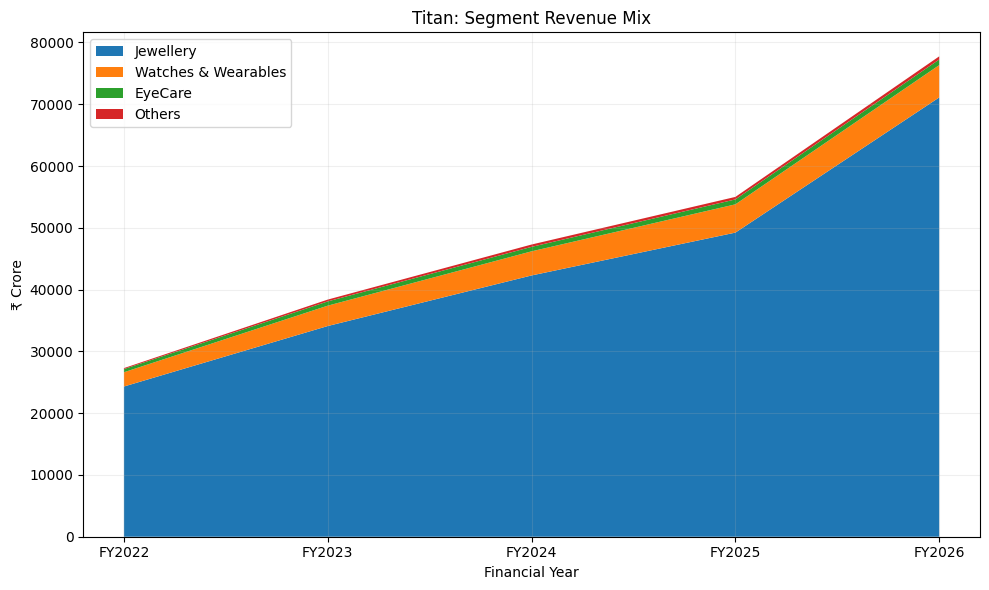

In [24]:
plt.figure(figsize=(10, 6))

plt.stackplot(
    segments["FY"],
    segments["Jewellery_revenue_₹Cr"],
    segments["Watches_revenue_₹Cr"],
    segments["Eyecare_revenue_₹Cr"],
    segments["Others_revenue_₹Cr"],
    labels=[
        "Jewellery",
        "Watches & Wearables",
        "EyeCare",
        "Others"
    ]
)

plt.title("Titan: Segment Revenue Mix")
plt.xlabel("Financial Year")
plt.ylabel("₹ Crore")
plt.legend(loc="upper left")
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [25]:
profit_data = segments[
    [
        "FY",
        "Watches_profit_₹Cr",
        "Jewellery_profit_₹Cr",
        "Eyecare_profit_₹Cr",
        "Others_profit_₹Cr"
    ]
]

display(profit_data.round(2))

,FY,Watches_profit_₹Cr,Jewellery_profit_₹Cr,Eyecare_profit_₹Cr,Others_profit_₹Cr
0,FY2022,108,3027,50,-36
1,FY2023,413,4363,98,-78
2,FY2024,397,4726,85,-93
3,FY2025,553,4764,85,-124
4,FY2026,842,6601,84,-114


In [26]:
segments["Watches_Margin_%"] = (
    segments["Watches_profit_₹Cr"] /
    segments["Watches_revenue_₹Cr"]
) * 100

segments["Jewellery_Margin_%"] = (
    segments["Jewellery_profit_₹Cr"] /
    segments["Jewellery_revenue_₹Cr"]
) * 100

segments["Eyecare_Margin_%"] = (
    segments["Eyecare_profit_₹Cr"] /
    segments["Eyecare_revenue_₹Cr"]
) * 100

segments["Others_Margin_%"] = (
    segments["Others_profit_₹Cr"] /
    segments["Others_revenue_₹Cr"]
) * 100

segment_margins = segments[
    [
        "FY",
        "Watches_Margin_%",
        "Jewellery_Margin_%",
        "Eyecare_Margin_%",
        "Others_Margin_%"
    ]
]

display(segment_margins.round(2))

,FY,Watches_Margin_%,Jewellery_Margin_%,Eyecare_Margin_%,Others_Margin_%
0,FY2022,4.68,12.45,9.67,-23.38
1,FY2023,12.53,12.79,14.22,-26.44
2,FY2024,10.17,11.17,11.74,-24.60
3,FY2025,12.08,9.68,10.68,-30.54
4,FY2026,16.09,9.28,9.26,-22.44


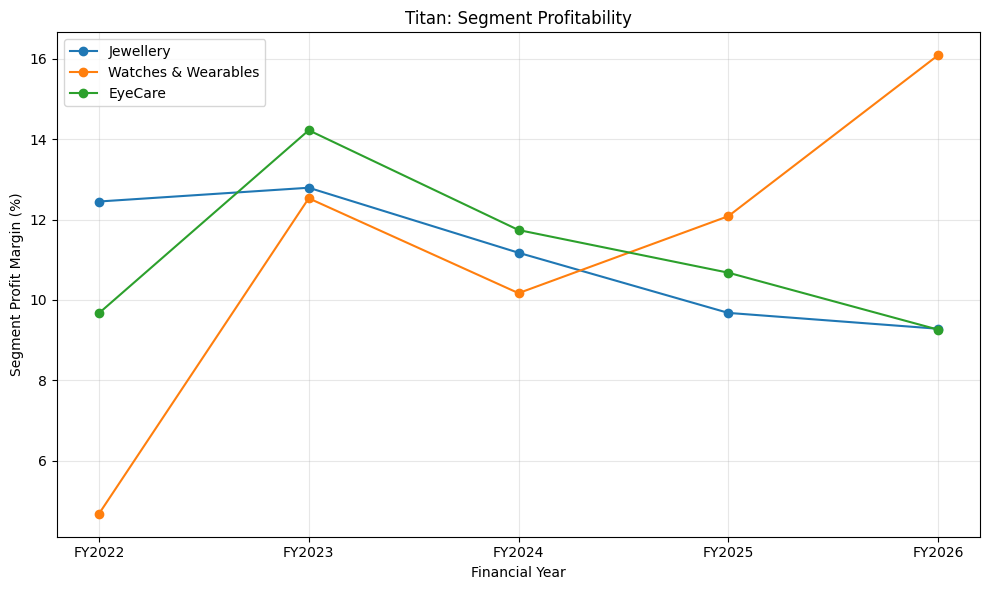

In [27]:
plt.figure(figsize=(10, 6))

plt.plot(
    segments["FY"],
    segments["Jewellery_Margin_%"],
    marker="o",
    label="Jewellery"
)

plt.plot(
    segments["FY"],
    segments["Watches_Margin_%"],
    marker="o",
    label="Watches & Wearables"
)

plt.plot(
    segments["FY"],
    segments["Eyecare_Margin_%"],
    marker="o",
    label="EyeCare"
)

plt.title("Titan: Segment Profitability")
plt.xlabel("Financial Year")
plt.ylabel("Segment Profit Margin (%)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [28]:
segment_growth_summary = []

for col in segment_revenue_columns:

    segment_name = (
        col.replace("_revenue_₹Cr", "")
    )

    start_value = segments.iloc[0][col]
    end_value = segments.iloc[-1][col]

    cagr = (
        (end_value / start_value) **
        (1 / years)
    ) - 1

    absolute_change = end_value - start_value

    segment_growth_summary.append({
        "Segment": segment_name,
        "FY22 Revenue": start_value,
        "FY26 Revenue": end_value,
        "Absolute Increase": absolute_change,
        "CAGR %": cagr * 100
    })

segment_growth = pd.DataFrame(segment_growth_summary)

display(segment_growth.round(2))

,Segment,FY22 Revenue,FY26 Revenue,Absolute Increase,CAGR %
0,Watches,2309,5233,2924,22.70
1,Jewellery,24313,71108,46795,30.77
2,Eyecare,517,907,390,15.09
3,Others,154,508,354,34.77


In [29]:
peer_analysis = peers[
    [
        "Company",
        "Total_income_₹Cr",
        "EBITDA_₹Cr",
        "PAT_₹Cr",
        "EBITDA_margin_%",
        "PAT_margin_%"
    ]
].copy()

display(peer_analysis.round(2))

,Company,Total_income_₹Cr,EBITDA_₹Cr,PAT_₹Cr,EBITDA_margin_%,PAT_margin_%
0,Titan (FY2025),"60,942.00","6,180.00","3,337.00",10.14,5.48
1,Kalyan Jewellers (FY2025),"25,189.67","1,517.20",714.17,6.02,2.84
2,Senco Gold (FY2025),"6,382.64",367.63,159.31,5.76,2.50
3,Ethos (FY2025),"1,275.93",214.30,96.30,16.80,7.55


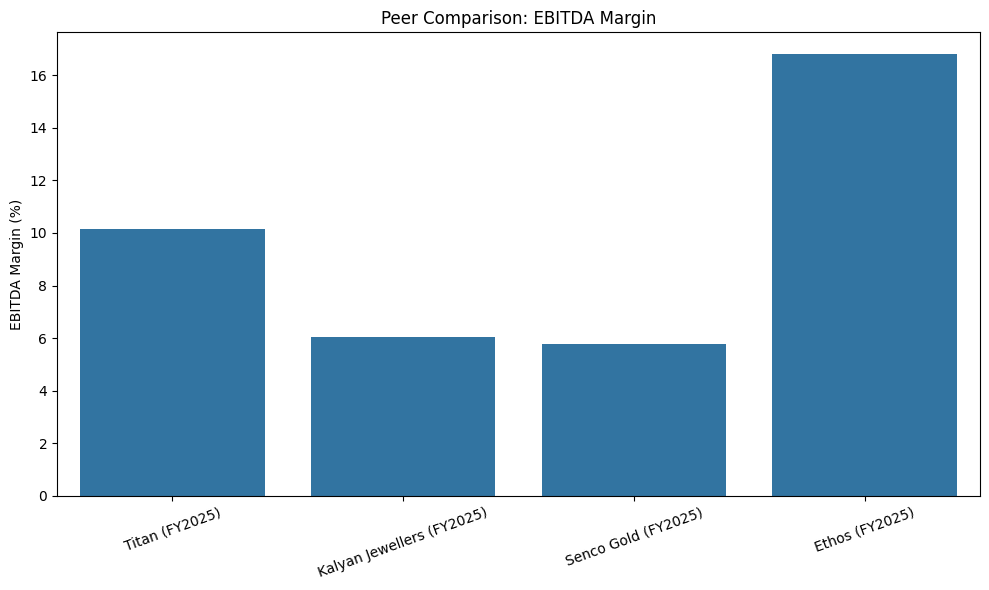

In [30]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=peer_analysis,
    x="Company",
    y="EBITDA_margin_%"
)

plt.title("Peer Comparison: EBITDA Margin")
plt.xlabel("")
plt.ylabel("EBITDA Margin (%)")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

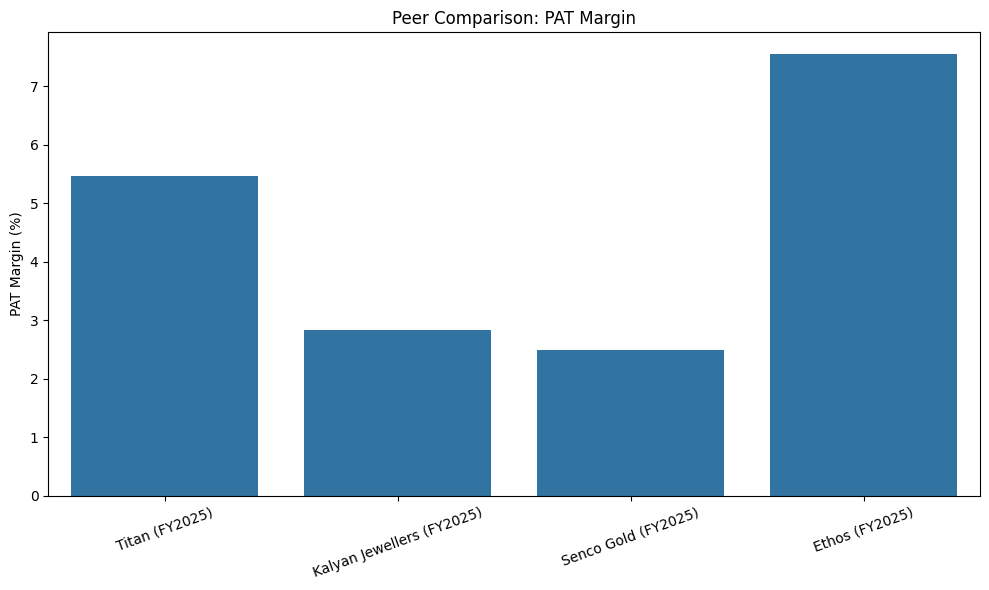

In [31]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=peer_analysis,
    x="Company",
    y="PAT_margin_%"
)

plt.title("Peer Comparison: PAT Margin")
plt.xlabel("")
plt.ylabel("PAT Margin (%)")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [33]:
titan_peer = peer_analysis[
    peer_analysis["Company"].str.contains("Titan")
].iloc[0]

peer_average_ebitda = peer_analysis[
    ~peer_analysis["Company"].str.contains("Titan")
]["EBITDA_margin_%"].mean()

peer_average_pat = peer_analysis[
    ~peer_analysis["Company"].str.contains("Titan")
]["PAT_margin_%"].mean()

print("Titan EBITDA Margin:",
      round(titan_peer["EBITDA_margin_%"], 2), "%")

print("Peer Average EBITDA Margin:",
      round(peer_average_ebitda, 2), "%")

print()

print("Titan PAT Margin:",
      round(titan_peer["PAT_margin_%"], 2), "%")

print("Peer Average PAT Margin:",
      round(peer_average_pat, 2), "%")

Titan EBITDA Margin: 10.14 %
Peer Average EBITDA Margin: 9.53 %

Titan PAT Margin: 5.48 %
Peer Average PAT Margin: 4.29 %


In [35]:
correlation_data = financials[
    [
        "Revenue_from_operations_₹Cr",
        "EBITDA_proxy_₹Cr",
        "PBT_₹Cr",
        "PAT_₹Cr",
        "EBITDA_Margin_Calc_%",
        "PAT_Margin_Calc_%"
    ]
]

correlation_matrix = correlation_data.corr()

display(correlation_matrix.round(2))

,Revenue_from_operations_₹Cr,EBITDA_proxy_₹Cr,PBT_₹Cr,PAT_₹Cr,EBITDA_Margin_Calc_%,PAT_Margin_Calc_%
Revenue_from_operations_₹Cr,1.00,0.99,0.95,0.95,-0.86,-0.81
EBITDA_proxy_₹Cr,0.99,1.00,0.99,0.99,-0.78,-0.72
PBT_₹Cr,0.95,0.99,1.00,1.00,-0.67,-0.60
PAT_₹Cr,0.95,0.99,1.00,1.00,-0.67,-0.60
EBITDA_Margin_Calc_%,-0.86,-0.78,-0.67,-0.67,1.00,0.99
PAT_Margin_Calc_%,-0.81,-0.72,-0.60,-0.60,0.99,1.00


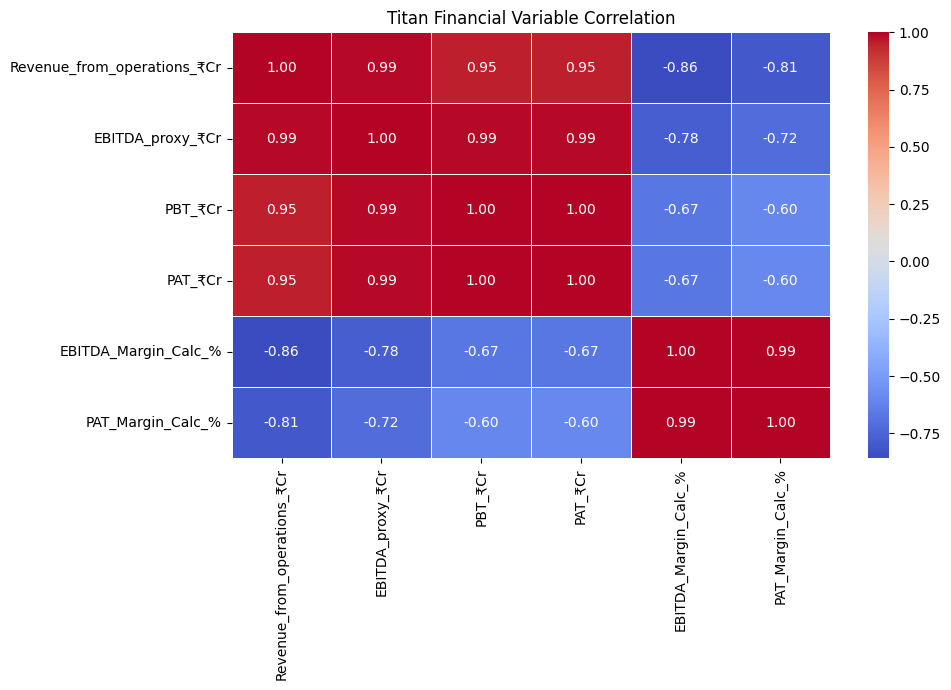

In [36]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Titan Financial Variable Correlation")
plt.tight_layout()
plt.show()

In [37]:
latest = segments.iloc[-1]

fy26_segment_revenue = pd.DataFrame({
    "Segment": [
        "Jewellery",
        "Watches & Wearables",
        "EyeCare",
        "Others"
    ],
    "Revenue": [
        latest["Jewellery_revenue_₹Cr"],
        latest["Watches_revenue_₹Cr"],
        latest["Eyecare_revenue_₹Cr"],
        latest["Others_revenue_₹Cr"]
    ]
})

fy26_segment_revenue["Contribution_%"] = (
    fy26_segment_revenue["Revenue"] /
    fy26_segment_revenue["Revenue"].sum()
) * 100

display(fy26_segment_revenue.round(2))

,Segment,Revenue,Contribution_%
0,Jewellery,71108,91.45
1,Watches & Wearables,5233,6.73
2,EyeCare,907,1.17
3,Others,508,0.65


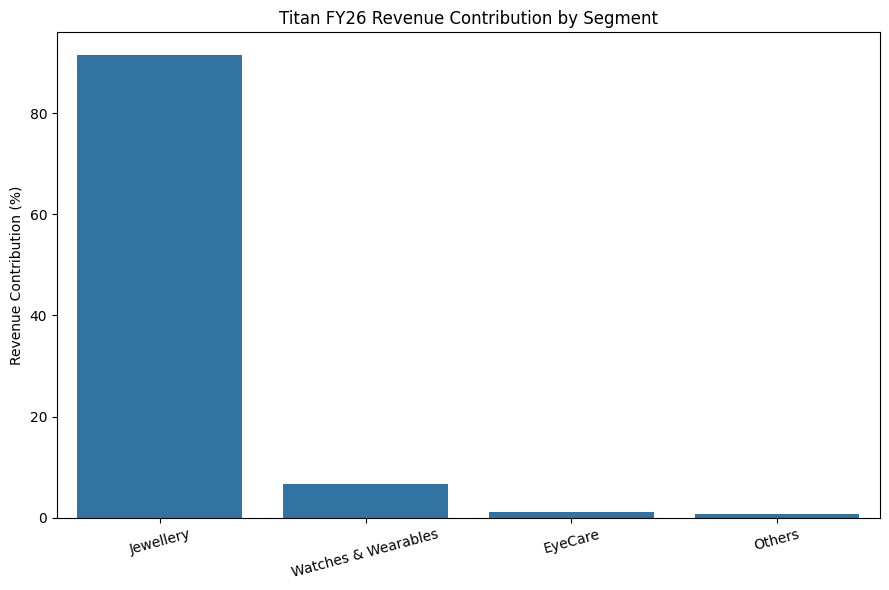

In [38]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=fy26_segment_revenue,
    x="Segment",
    y="Contribution_%"
)

plt.title("Titan FY26 Revenue Contribution by Segment")
plt.xlabel("")
plt.ylabel("Revenue Contribution (%)")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [39]:
fy26_segment_profit = pd.DataFrame({
    "Segment": [
        "Jewellery",
        "Watches & Wearables",
        "EyeCare",
        "Others"
    ],
    "Profit": [
        latest["Jewellery_profit_₹Cr"],
        latest["Watches_profit_₹Cr"],
        latest["Eyecare_profit_₹Cr"],
        latest["Others_profit_₹Cr"]
    ]
})

fy26_segment_profit["Profit_Contribution_%"] = (
    fy26_segment_profit["Profit"] /
    fy26_segment_profit["Profit"].sum()
) * 100

display(fy26_segment_profit.round(2))

,Segment,Profit,Profit_Contribution_%
0,Jewellery,6601,89.05
1,Watches & Wearables,842,11.36
2,EyeCare,84,1.13
3,Others,-114,-1.54


In [40]:
latest_revenue = financials.iloc[-1]["Revenue_from_operations_₹Cr"]

scenarios = pd.DataFrame({
    "Scenario": [
        "Bear Case",
        "Base Case",
        "Bull Case"
    ],
    "Revenue_Growth_Assumption_%": [
        10,
        15,
        20
    ]
})

scenarios["FY27_Revenue_₹Cr"] = (
    latest_revenue *
    (1 + scenarios["Revenue_Growth_Assumption_%"] / 100)
)

display(scenarios.round(2))

,Scenario,Revenue_Growth_Assumption_%,FY27_Revenue_₹Cr
0,Bear Case,10,"96,342.40"
1,Base Case,15,"100,721.60"
2,Bull Case,20,"105,100.80"


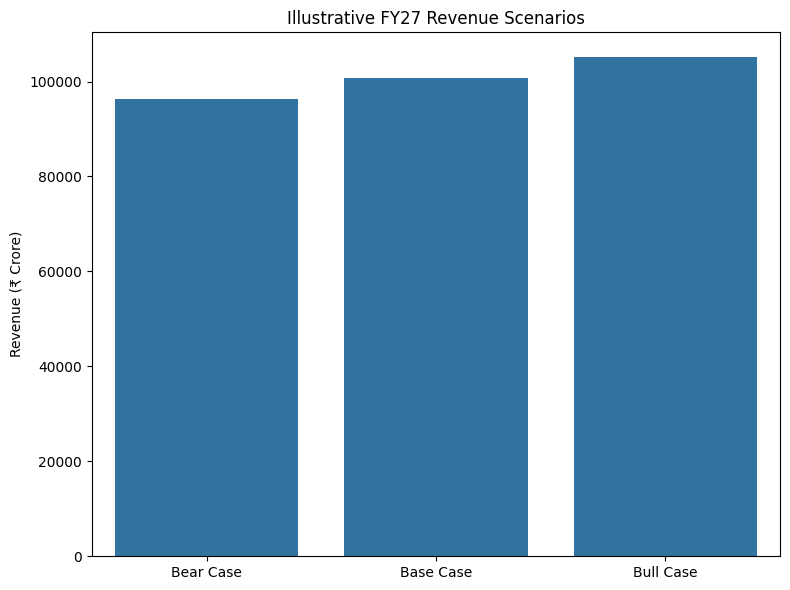

In [41]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=scenarios,
    x="Scenario",
    y="FY27_Revenue_₹Cr"
)

plt.title("Illustrative FY27 Revenue Scenarios")
plt.xlabel("")
plt.ylabel("Revenue (₹ Crore)")

plt.tight_layout()
plt.show()

In [42]:
base_revenue = scenarios.loc[
    scenarios["Scenario"] == "Base Case",
    "FY27_Revenue_₹Cr"
].iloc[0]

margin_scenarios = pd.DataFrame({
    "EBITDA_Margin": [
        9,
        10,
        11,
        12
    ]
})

margin_scenarios["Implied_EBITDA_₹Cr"] = (
    base_revenue *
    margin_scenarios["EBITDA_Margin"] / 100
)

display(margin_scenarios.round(2))

,EBITDA_Margin,Implied_EBITDA_₹Cr
0,9,"9,064.94"
1,10,"10,072.16"
2,11,"11,079.38"
3,12,"12,086.59"


In [43]:
insights = pd.DataFrame({
    "Analysis Area": [
        "Revenue growth",
        "Profit growth",
        "Margin trend",
        "Segment concentration",
        "Competitive benchmark",
        "Scenario analysis"
    ],
    "What We Examine": [
        "Long-term revenue CAGR and annual growth",
        "EBITDA and PAT growth relative to revenue",
        "EBITDA and PAT margin movement",
        "Which businesses drive revenue and profit",
        "Titan's margins relative to selected peers",
        "Revenue and margin sensitivity under scenarios"
    ]
})

display(insights)

,Analysis Area,What We Examine
0,Revenue growth,Long-term revenue CAGR and annual growth
1,Profit growth,EBITDA and PAT growth relative to revenue
2,Margin trend,EBITDA and PAT margin movement
3,Segment concentration,Which businesses drive revenue and profit
4,Competitive benchmark,Titan's margins relative to selected peers
5,Scenario analysis,Revenue and margin sensitivity under scenarios


In [44]:
initial_revenue = financials.iloc[0]["Revenue_from_operations_₹Cr"]
final_revenue = financials.iloc[-1]["Revenue_from_operations_₹Cr"]

initial_pat = financials.iloc[0]["PAT_₹Cr"]
final_pat = financials.iloc[-1]["PAT_₹Cr"]

initial_ebitda_margin = financials.iloc[0]["EBITDA_Margin_Calc_%"]
final_ebitda_margin = financials.iloc[-1]["EBITDA_Margin_Calc_%"]

initial_pat_margin = financials.iloc[0]["PAT_Margin_Calc_%"]
final_pat_margin = financials.iloc[-1]["PAT_Margin_Calc_%"]

print("========== TITAN KEY FINDINGS ==========\n")

print(f"Revenue increased from ₹{initial_revenue:,.0f} Cr "
      f"to ₹{final_revenue:,.0f} Cr.")

print(f"Revenue CAGR: {revenue_cagr*100:.2f}%")

print(f"EBITDA CAGR: {ebitda_cagr*100:.2f}%")

print(f"PAT CAGR: {pat_cagr*100:.2f}%")

print(
    f"\nEBITDA margin changed from "
    f"{initial_ebitda_margin:.2f}% to "
    f"{final_ebitda_margin:.2f}%."
)

print(
    f"PAT margin changed from "
    f"{initial_pat_margin:.2f}% to "
    f"{final_pat_margin:.2f}%."
)

print(
    f"\nEBITDA margin change: "
    f"{final_ebitda_margin - initial_ebitda_margin:.2f} percentage points."
)

print(
    f"PAT margin change: "
    f"{final_pat_margin - initial_pat_margin:.2f} percentage points."
)

========== TITAN KEY FINDINGS ==========

Revenue increased from ₹28,799 Cr to ₹87,584 Cr.
Revenue CAGR: 32.06%
EBITDA CAGR: 25.64%
PAT CAGR: 23.26%

EBITDA margin changed from 12.31% to 10.11%.
PAT margin changed from 7.57% to 5.76%.

EBITDA margin change: -2.21 percentage points.
PAT margin change: -1.81 percentage points.


In [45]:
output_file = "Titan_Python_Analysis.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:

    financial_analysis.to_excel(
        writer,
        sheet_name="Financial_Analysis",
        index=False
    )

    segment_growth.to_excel(
        writer,
        sheet_name="Segment_Growth",
        index=False
    )

    segment_margins.to_excel(
        writer,
        sheet_name="Segment_Margins",
        index=False
    )

    peer_analysis.to_excel(
        writer,
        sheet_name="Peer_Benchmark",
        index=False
    )

    scenarios.to_excel(
        writer,
        sheet_name="Scenarios",
        index=False
    )

print("Analysis exported successfully.")

Analysis exported successfully.


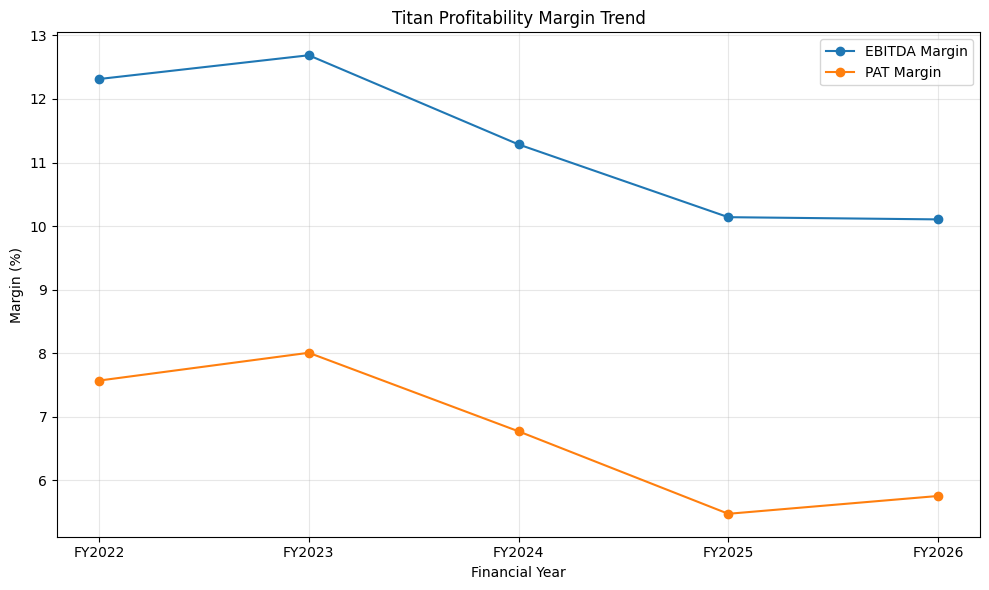

In [46]:
plt.figure(figsize=(10, 6))

plt.plot(
    financials["FY"],
    financials["EBITDA_Margin_Calc_%"],
    marker="o",
    label="EBITDA Margin"
)

plt.plot(
    financials["FY"],
    financials["PAT_Margin_Calc_%"],
    marker="o",
    label="PAT Margin"
)

plt.title("Titan Profitability Margin Trend")
plt.xlabel("Financial Year")
plt.ylabel("Margin (%)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Titan_Profitability_Trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [47]:
dashboard_data = financials[
    [
        "FY",
        "Revenue_from_operations_₹Cr",
        "EBITDA_proxy_₹Cr",
        "PAT_₹Cr",
        "Revenue_Growth_%",
        "EBITDA_Growth_%",
        "PAT_Growth_%",
        "EBITDA_Margin_Calc_%",
        "PAT_Margin_Calc_%"
    ]
].copy()

dashboard_data.to_csv(
    "Titan_Dashboard_Data.csv",
    index=False
)

display(dashboard_data.round(2))

,FY,Revenue_from_operations_₹Cr,EBITDA_proxy_₹Cr,PAT_₹Cr,Revenue_Growth_%,EBITDA_Growth_%,PAT_Growth_%,EBITDA_Margin_Calc_%,PAT_Margin_Calc_%
0,FY2022,"28,799.00","3,575.00","2,198.00",NaN,NaN,NaN,12.31,7.57
1,FY2023,"40,575.00","5,187.00","3,274.00",40.89,45.09,48.95,12.69,8.01
2,FY2024,"51,084.00","5,825.00","3,496.00",25.90,12.30,6.78,11.29,6.77
3,FY2025,"60,456.00","6,180.00","3,337.00",18.35,6.09,-4.55,10.14,5.48
4,FY2026,"87,584.00","8,907.00","5,073.00",44.87,44.13,52.02,10.11,5.76


In [48]:
from google.colab import files

files.download("Titan_Python_Analysis.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [49]:
files.download("Titan_Dashboard_Data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>